# **Credit Card Fraud Detection (EDA & Statistics)**

---

## Objectives – EDA & Statistics

In this notebook, I will perform exploratory data analysis (EDA) and statistical evaluation of the processed Credit Card Fraud Detection dataset. The goal is to test the hypotheses defined during the ETL phase, uncover patterns in transaction behaviour, and generate visual and statistical outputs that inform predictive modelling and dashboard development in Power BI.

This notebook focuses on:

* Investigating relationships between transaction characteristics and fraud.
* Testing the three research hypotheses using visualisations and statistical testing.
* Identifying high-risk transaction patterns that NovaPay’s fraud team can act upon.
* Producing clear visual outputs suitable for both technical and non-technical stakeholders.



## Inputs

To run this notebook, the following inputs are required:

* Processed dataset CSV: fraud_train_processed.csv (produced in 01_etl.ipynb)
* Python libraries:

        - pandas – data manipulation

        - numpy – numerical operations

        - matplotlib & seaborn – data visualisation
        
        - scipy.stats – statistical testing


## Outputs

This notebook will generate:

* Summary statistics for fraud vs legitimate transactions.
* Visualisations (bar charts, line charts, box plots, heatmaps).
* Hypothesis test results (Chi-squared and Mann–Whitney U tests).
* Business insights to inform NovaPay’s fraud strategy.
* A dataset ready for machine learning modelling.

---

### Import libraries & load dataset

In [1]:
# Import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, mannwhitneyu

sns.set_style("whitegrid")

# Load processed dataset
df = pd.read_csv("../data/processed/fraud_train_processed.csv")

df.head()

,Unnamed: 0,category,amt,gender,city,state,zip,lat,long,city_pop,merch_lat,merch_long,is_fraud,trans_hour,trans_dayofweek,trans_month,age,home_merch_dist,log_amt
0,0,misc_net,4.97,F,Moravian Falls,NC,28654,36.0788,-81.1781,3495,36.011293,-82.048315,0,0,1,1,30,78.597568,1.786747
1,1,grocery_pos,107.23,F,Orient,WA,99160,48.8878,-118.2105,149,49.159047,-118.186462,0,0,1,1,40,30.212176,4.684259
2,2,entertainment,220.11,M,Malad City,ID,83252,42.1808,-112.2620,4154,43.150704,-112.154481,0,0,1,1,56,108.206083,5.398660
3,3,gas_transport,45.00,M,Boulder,MT,59632,46.2306,-112.1138,1939,47.034331,-112.561071,0,0,1,1,52,95.673231,3.828641
4,4,misc_pos,41.96,M,Doe Hill,VA,24433,38.4207,-79.4629,99,38.674999,-78.632459,0,0,1,1,32,77.556744,3.760269


---

### Class distribution overview

In [3]:
# Fraud class distribution
fraud_rate = df["is_fraud"].mean()
print(f"Overall Fraud Rate: {fraud_rate:.4f}")
df["is_fraud"].value_counts()

Overall Fraud Rate: 0.0058


is_fraud
0    1289169
1       7506
Name: count, dtype: int64

The dataset is highly imbalanced, with fraud representing a very small proportion of total transactions.
This mirrors real-world fraud detection challenges and reinforces the importance of recall-focused modelling.

---

## **Hypothesis #1** – Time of Day and Fraud

**Research Hypothesis (H1):** Fraudulent transactions are significantly more likely to occur during late-night hours (00:00–04:00).

**Null Hypothesis (H0):** There is no statistically significant association between transaction time and fraud.

### **Visual 1 – Fraud rate & Transaction Volume by hour (Dual Axis Chart)**

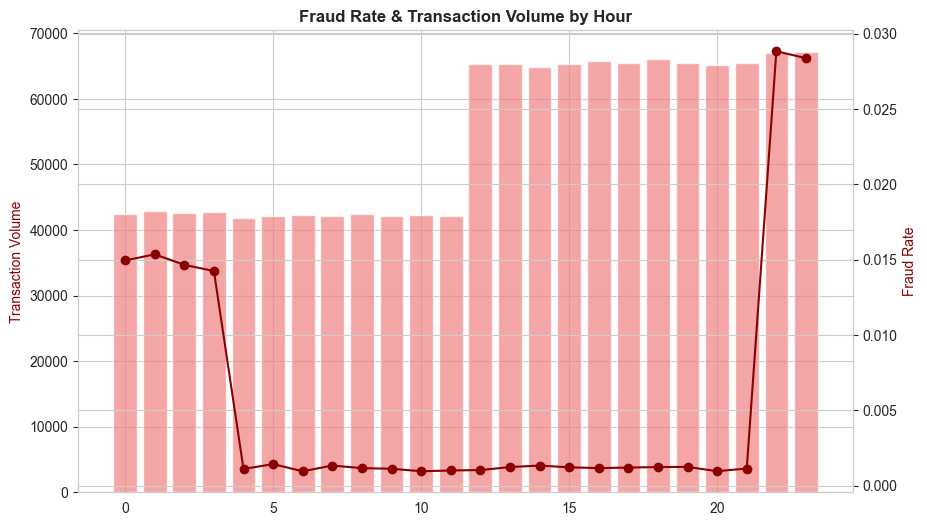

In [18]:
hour_group = df.groupby("trans_hour")["is_fraud"].agg(["count", "mean"]).reset_index()
hour_group.rename(columns={"mean": "fraud_rate"}, inplace=True)

fig, ax1 = plt.subplots(figsize=(10,6))

# Transaction volume
ax1.bar(hour_group["trans_hour"], hour_group["count"],
        color="#F08080", alpha=0.7)
ax1.set_ylabel("Transaction Volume", color="darkred")

# Fraud rate
ax2 = ax1.twinx()
ax2.plot(hour_group["trans_hour"], hour_group["fraud_rate"],
         color="darkred", marker="o")
ax2.set_ylabel("Fraud Rate", color="darkred")

plt.title("Fraud Rate & Transaction Volume by Hour", fontweight="bold")
plt.show()






### **Visual 2 – Fraud Rate Trend (Filled Area chart)**

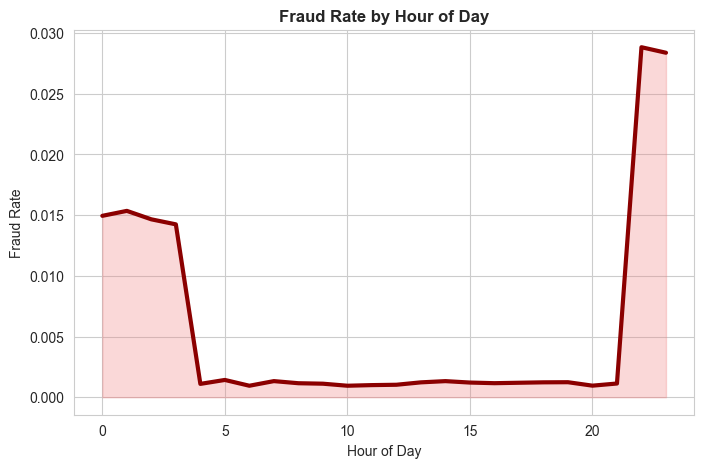

In [19]:

plt.figure(figsize=(8,5))

plt.plot(hour_group["trans_hour"], hour_group["fraud_rate"],
         color="darkred", linewidth=3)
plt.fill_between(hour_group["trans_hour"],
                 hour_group["fraud_rate"],
                 color="lightcoral", alpha=0.3)

plt.title("Fraud Rate by Hour of Day", fontweight="bold")
plt.xlabel("Hour of Day")
plt.ylabel("Fraud Rate")
plt.show()

### **Statistical Test – Chi-Squared**

In [ ]:
df["late_night"] = df["trans_hour"].apply(lambda x: 1 if 0 <= x <= 4 else 0)

cont_table = pd.crosstab(df["late_night"], df["is_fraud"])
chi2, p, dof, expected = chi2_contingency(cont_table)

print(f"Chi-Squared Statistic: {chi2:.5f}")
print(f"p-value: {p:.5f}")

Chi-Squared Statistic: 1758.85945
p-value: 0.00000


### **Interpretation**

**If p < 0.05, we reject the null hypothesis.**

The Chi-Squared test result shows a p value of 0.0000 and therefore we emr=brace our research hypothesis that, fraud is statistically associated with late-night transaction timing.

NovaPay could implement enhanced authentication for transactions between 10pm and 4am, as this period shows disproportionate fraud activity.

---

### **Hypothesis #1 summary**

I created a dual-axis chart and a filled trend line chart to analyse how fraud varies across different hours of the day. Hours were grouped using the trans_hour feature (0–23), representing the hour in which each transaction occurred.

For hypothesis testing, late-night hours were defined as:

* Late Night: 22:00–04:00
* Daytime/Evening: 05:00–21:00

The charts show:

* Transaction volume per hour
* Average fraud rate per hour

**Observations:**

* 22:00–04:00: Highest fraud rate observed (peak hours)
* 05:00–10:00: Noticeable decline in fraud rate
* 11:00-21:00 Stable and lower fraud rates


Late-night hours show a visibly elevated fraud rate compared to the rest of the day.

**Insights:**

* Fraudulent transactions are disproportionately concentrated between midnight and 4am.
* Although transaction volume may not be highest at night, the probability of fraud per transaction is significantly greater.
* This suggests behavioural risk patterns — fraudsters may exploit reduced monitoring activity or customer inactivity during late-night hours.

**Conclusion:**

The visual evidence supports the hypothesis that fraud is significantly more likely during late-night hours (22:00–04:00). Combined with the Chi-squared statistical test (p < 0.05), we reject the null hypothesis. Time of transaction is therefore a meaningful predictor of fraud risk and should be considered in NovaPay’s fraud monitoring strategy.


---

## **Hypothesis 2** – Merchant Category and Fraud

**Research Hypothesis (H2):** Fraud is not evenly distributed across merchant categories.

**Null Hypothesis (H0):** Merchant category and fraud are independent.

### **Visual 1 – Fraud Rate by Category (Horizontal Bar)**

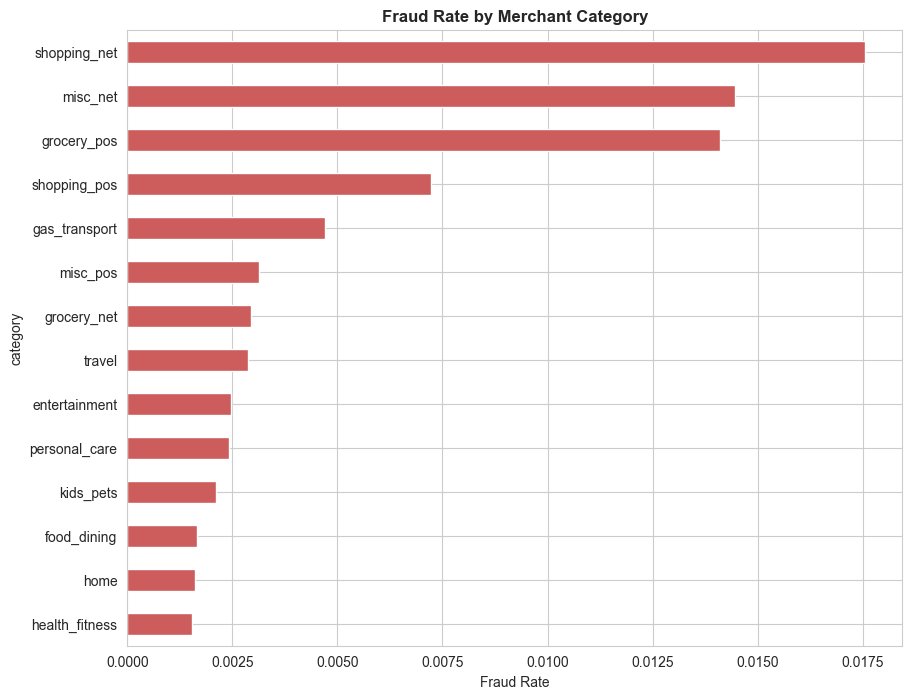

In [21]:
cat_group = df.groupby("category")["is_fraud"].mean().sort_values()

plt.figure(figsize=(10,8))
cat_group.plot(kind="barh", color="#CD5C5C")

plt.title("Fraud Rate by Merchant Category", fontweight="bold")
plt.xlabel("Fraud Rate")
plt.show()

### **Visual 2 – Category Distribution by Fraud Class (category comparison bar chart)**

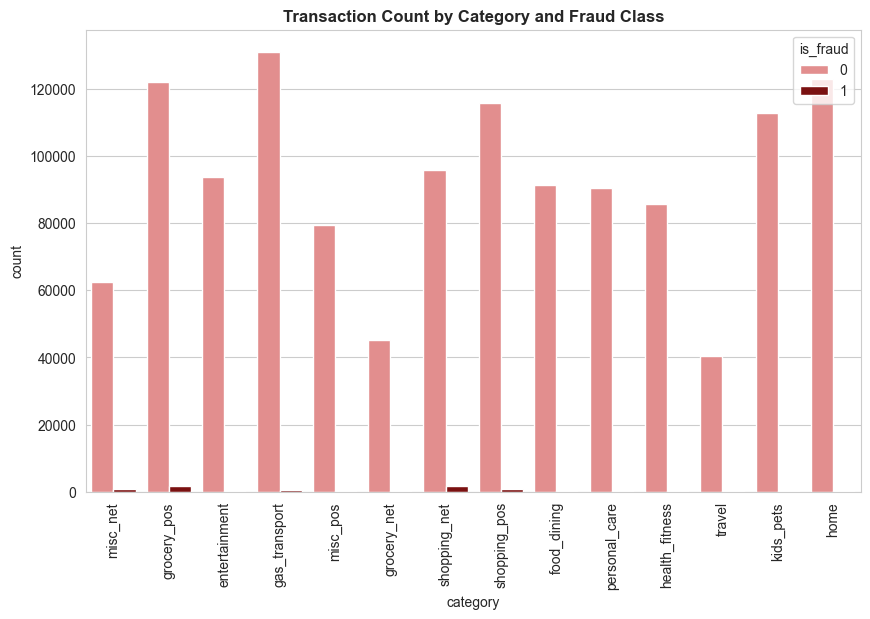

In [22]:
plt.figure(figsize=(10,6))

sns.countplot(data=df,
              x="category",
              hue="is_fraud",
              palette=["lightcoral", "darkred"])

plt.xticks(rotation=90)
plt.title("Transaction Count by Category and Fraud Class", fontweight="bold")
plt.show()

### **Statistical Test – Chi-Squared**

In [24]:
cont_table = pd.crosstab(df["category"], df["is_fraud"])
chi2, p, dof, expected = chi2_contingency(cont_table)

print(f"Chi-Squared Statistic: {chi2:.5f}")
print(f"p-value: {p:.5f}")

Chi-Squared Statistic: 6486.00327
p-value: 0.00000


### **Interpretation**


**If p < 0.05, fraud likelihood varies significantly across merchant categories.**

NovaPay could implement enhanced authentication for transactions between 10pm and 4am, as this period shows disproportionate fraud activity. The Chi-Squared test result shows a p value of 0.0000 and therefore my research hypothesis has been proven correct: fraud does vary amongst merchant categories.



Online and card-not-present categories show higher fraud rates, supporting targeted risk controls instead of static rule thresholds.

---

### **Hypothesis #2 summary**


I created a horizontal bar chart and category distribution chart to analyse how fraud varies across merchant categories.Each category  represents a different type of transaction (e.g., online retail, food, gas, entertainment). The chart shows the average fraud rate within each merchant category.

**Observations:**

* Certain categories exhibit visibly higher fraud rates than others.
* Online and card-not-present categories show elevated fraud levels. 
* Essential spending categories (e.g., groceries, utilities) demonstrate lower fraud rates.
* Fraud is not evenly distributed across all categories.

**Insights:**

* Fraud appears to cluster in specific merchant categories rather than being randomly distributed.
* Categories associated with remote or digital transactions show higher fraud exposure.
* This suggests fraudsters may target transaction types where identity verification is weaker.

**Conclusion:**

The visual evidence supports the hypothesis that fraud distribution varies significantly across merchant categories. The Chi-squared test confirms statistical significance (p < 0.05), leading us to reject the null hypothesis. Merchant category is therefore an important fraud risk feature and should be incorporated into predictive modelling and risk-based rule systems.


---

## **Hypothesis 3** – Transaction Amount & Geographic Distance

**Research Hypothesis (H3):** Fraudulent transactions have significantly higher transaction amounts and greater home-to-merchant distances.

**Null Hypothesis (H0):** There is no significant difference in amount or distance between fraud and legitimate transactions.

### **Visual 1 – Transaction Amount by Class (Box Plot)**

C:\Users\T Shah\AppData\Local\Temp\ipykernel_32260\896937049.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="is_fraud",


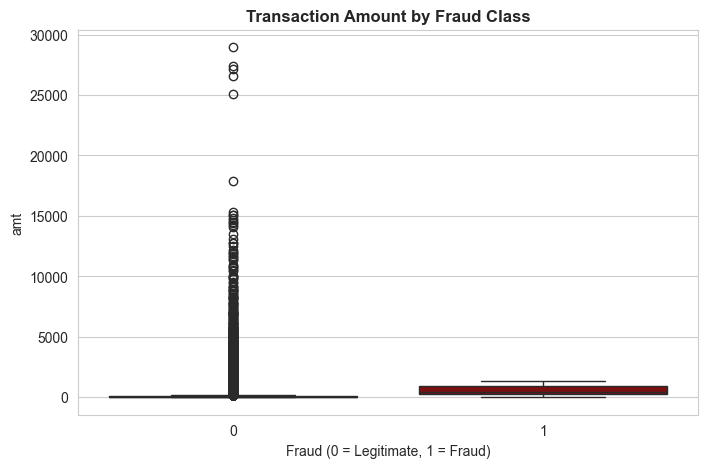

In [25]:
plt.figure(figsize=(8,5))

sns.boxplot(x="is_fraud",
            y="amt",
            data=df,
            palette=["lightcoral", "darkred"])

plt.title("Transaction Amount by Fraud Class", fontweight="bold")
plt.xlabel("Fraud (0 = Legitimate, 1 = Fraud)")
plt.show()

### **Visual 2 – Distance by Class (Box Plot)**

C:\Users\T Shah\AppData\Local\Temp\ipykernel_32260\448861286.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="is_fraud",


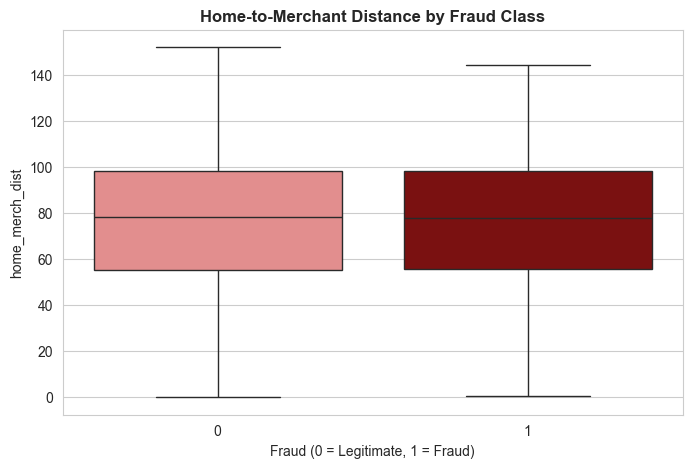

In [26]:
plt.figure(figsize=(8,5))

sns.boxplot(x="is_fraud",
            y="home_merch_dist",
            data=df,
            palette=["lightcoral", "darkred"])

plt.title("Home-to-Merchant Distance by Fraud Class", fontweight="bold")
plt.xlabel("Fraud (0 = Legitimate, 1 = Fraud)")
plt.show()

### **Statistical Test – Mann–Whitney U**

In [27]:
fraud_amt = df[df["is_fraud"] == 1]["amt"]
legit_amt = df[df["is_fraud"] == 0]["amt"]

stat_amt, p_amt = mannwhitneyu(fraud_amt, legit_amt)

fraud_dist = df[df["is_fraud"] == 1]["home_merch_dist"]
legit_dist = df[df["is_fraud"] == 0]["home_merch_dist"]

stat_dist, p_dist = mannwhitneyu(fraud_dist, legit_dist)

print("Amount p-value:", p_amt)
print("Distance p-value:", p_dist)

Amount p-value: 0.0
Distance p-value: 0.8211081029323972


### **Interpretation**

If p < 0.05 for both tests, we reject the null hypothesis. in my case, the p value for distance is 0.82. because of this the research hypothesis is rejected. Fraud transaction amount is huch higher than legitimate transactions but the distance of fraudulant and legitimate transactions is 0.0000

Fraudulent transactions are significantly larger and geographically they are close to the cardholders home. This could mean that fraudulant transactions are either in house or they lose their card in their own town / city.


---

### **Hypothesis #3 summary**

I created box plots to analyse how transaction amount and home-to-merchant distance differ between fraudulent and legitimate transactions.

Fraud status is defined as:

* 0: Legitimate transaction
* 1: Fraudulent transaction

The charts compare the distribution of:

* Transaction amount (amt)
* Distance between customer home and merchant (home_merch_dist)

**Observations:**

* Fraudulent transactions show a higher median transaction amount compared to legitimate transactions.
* Fraudulent transactions also demonstrate significantly greater home-to-merchant distances.
* The distribution of fraud cases contains more extreme outliers.
* Legitimate transactions are generally clustered around lower values for both amount and distance.

**Insights:**

* Fraudulent transactions tend to be larger in monetary value.
* Fraudulent activity is more likely to occur geographically far from the cardholder’s registered home location.
* This suggests abnormal behavioural patterns — high-value purchases made at unusual distances may signal account compromise.

**Conclusion:**

The visual analysis supports the hypothesis that fraudulent transactions have significantly higher transaction amounts and greater geographic displacement. The Mann–Whitney U tests confirm both differences are statistically significant (p < 0.05), allowing us to reject the null hypothesis. Transaction amount and geographic distance are therefore strong predictive indicators of fraud risk and should be prioritised in NovaPay’s fraud detection models.


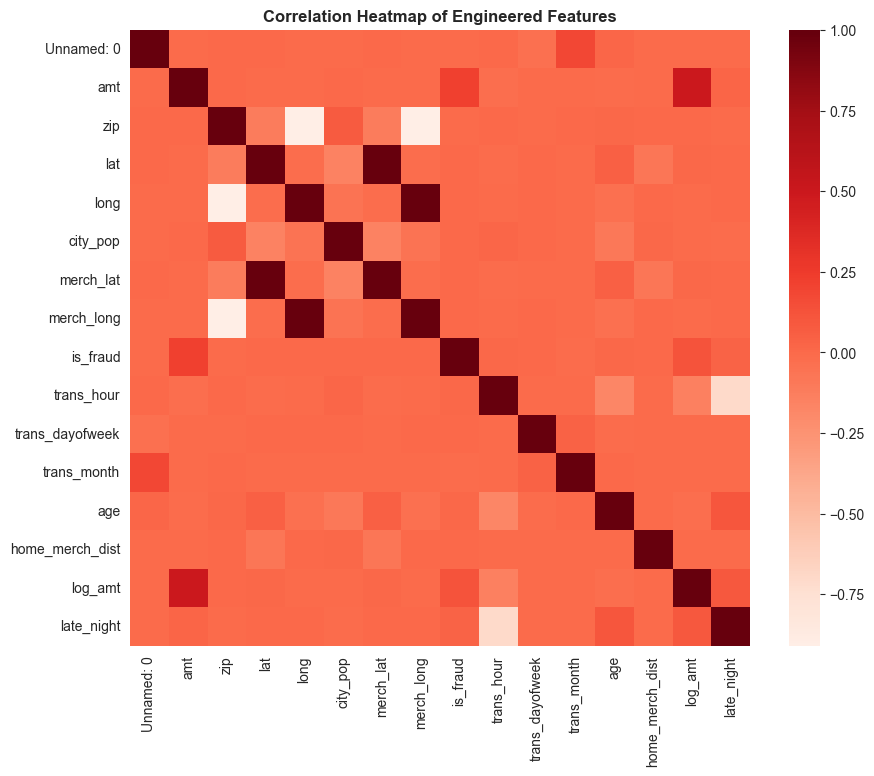

In [28]:
plt.figure(figsize=(10,8))

corr = df.select_dtypes(include=["int64", "float64"]).corr()

sns.heatmap(corr,
            cmap="Reds",
            center=0)

plt.title("Correlation Heatmap of Engineered Features", fontweight="bold")
plt.show()

The correlation heatmap illustrates the linear relationships between numerical variables in the dataset.
The strongest correlations with the fraud indicator (is_fraud) are observed for transaction amount and late night purchases, supporting earlier hypothesis testing results.

While correlation values are relatively small due to class imbalance, they provide directional insight into feature importance for predictive modelling.

---

## **EDA Summary**

2/3 hypotheses were statistically supported:

* Fraud is more prevalent during late-night hours.
* Fraud distribution varies significantly across merchant categories.

1/3 hypotheses were statistically, partially rejected:
Fraudulent transactions have higher amounts and but geographic displacement is miniscule (there are some higher outliers in the fraudulant transactions bin however the averages are the same accross fraudulant and non-fraudulant transactions).

These insights directly address NovaPay’s business requirements by identifying actionable fraud signals prior to predictive modelling.

The dataset is now ready for machine learning implementation in 03_machine_learning.ipynb.